In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("dim_locations_cleaned.csv")

display(df)

,Location_ID,Location_Name,Water_Body_Type,Latitude,Longitude,City,State,Nearby_Industry_Type
0,Loc-101,Hudson River North,River,40.7128,-74.0060,New York,Ny,Textile & Apparel
1,Loc-102,Lake Michigan Central,Lake,41.8781,-87.6298,Chicago,Il,Manufacturing
2,Loc-103,Bay Area Estuary,Estuary,37.7749,-122.4194,San Francisco,Ca,Tech & Commercial
3,Loc-104,City Wwtp Outlet,Wwtp Effluent,40.7306,-73.9352,New York,Ny,Municipal Sewage
4,Loc-105,Puget Sound Coastal,Coastal,47.6062,-122.3321,Seattle,Wa,Maritime & Shipping
5,Loc-106,Mississippi Delta,River,29.9511,-90.0715,New Orleans,La,Agriculture Runoff
6,Loc-107,Everglades Canal,Wetland,25.7617,-80.1918,Miami,Fl,Agriculture Runoff
7,Loc-108,Delaware River Basin,River,39.9526,-75.1652,Philadelphia,Pa,Chemical Processing
8,Loc-109,Lake Erie West,Lake,41.5055,-81.6944,Cleveland,Oh,Heavy Industrial
9,Loc-110,Chesapeake Inflow,Estuary,38.9784,-76.4922,Annapolis,Md,Urban Runoff


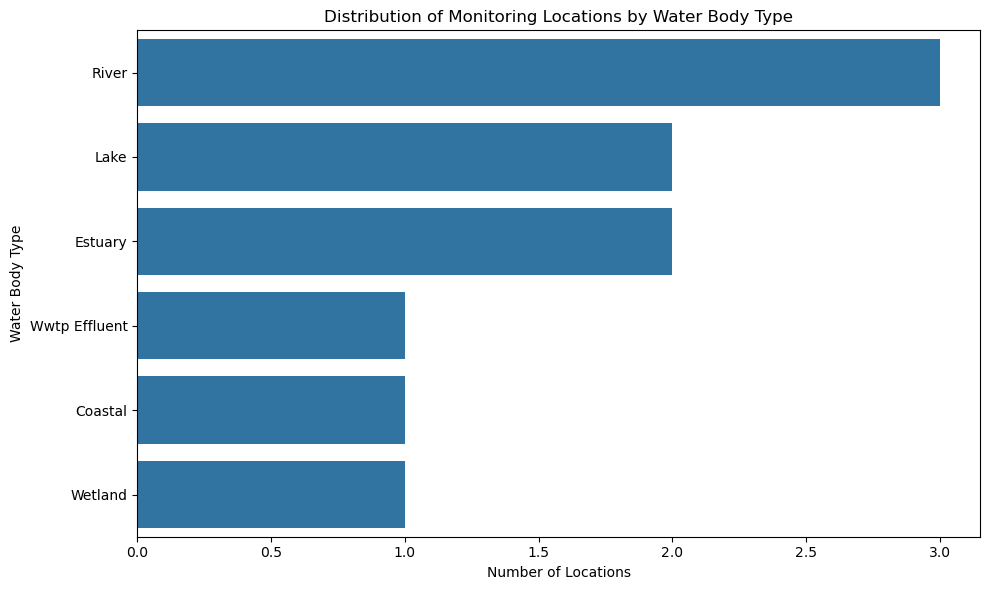

In [2]:
#Water body type distribution
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="Water_Body_Type",
    order=df["Water_Body_Type"].value_counts().index
)

plt.title("Distribution of Monitoring Locations by Water Body Type")
plt.xlabel("Number of Locations")
plt.ylabel("Water Body Type")
plt.tight_layout()
plt.show()

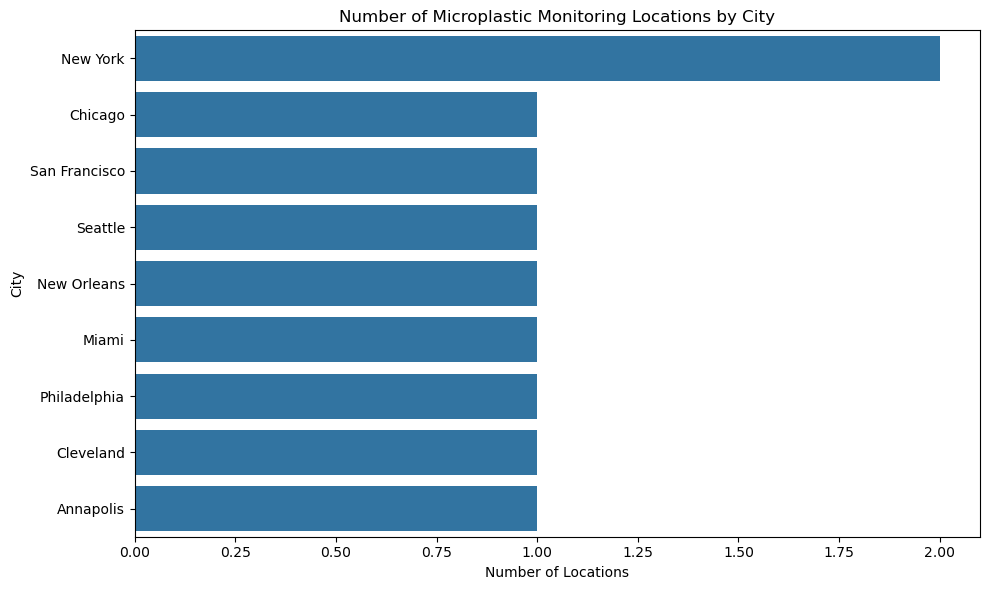

In [3]:
#Monitoring locations by city
plt.figure(figsize=(10, 6))

city_counts = df["City"].value_counts()

sns.barplot(
    x=city_counts.values,
    y=city_counts.index
)

plt.title("Number of Microplastic Monitoring Locations by City")
plt.xlabel("Number of Locations")
plt.ylabel("City")
plt.tight_layout()
plt.show()

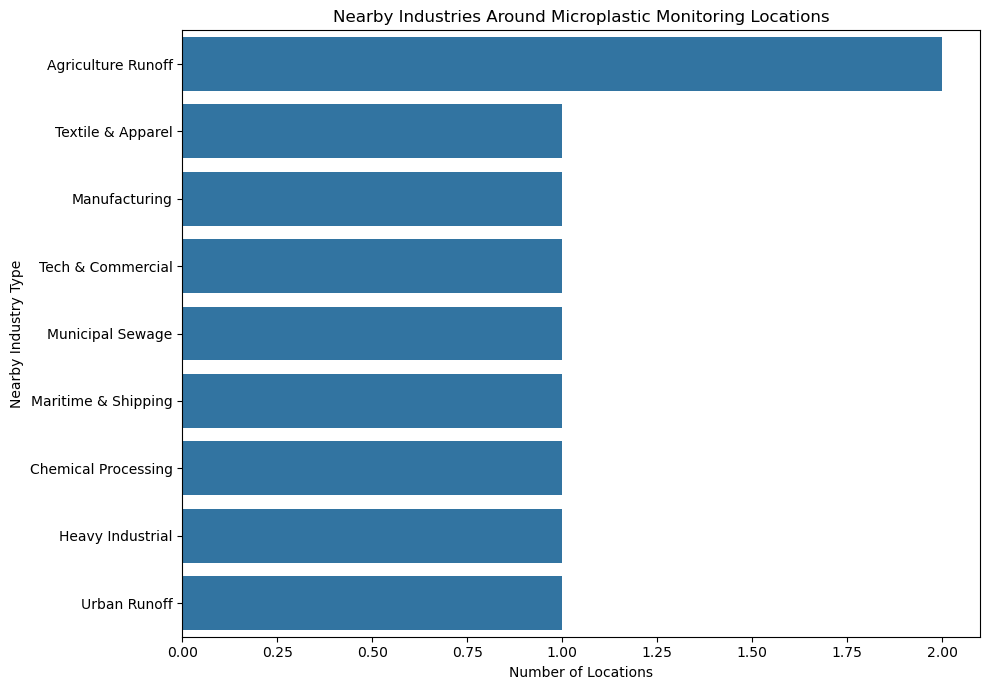

In [4]:
#Nearby industries
plt.figure(figsize=(10, 7))

industry_counts = df["Nearby_Industry_Type"].value_counts()

sns.barplot(
    x=industry_counts.values,
    y=industry_counts.index
)

plt.title("Nearby Industries Around Microplastic Monitoring Locations")
plt.xlabel("Number of Locations")
plt.ylabel("Nearby Industry Type")
plt.tight_layout()
plt.show()

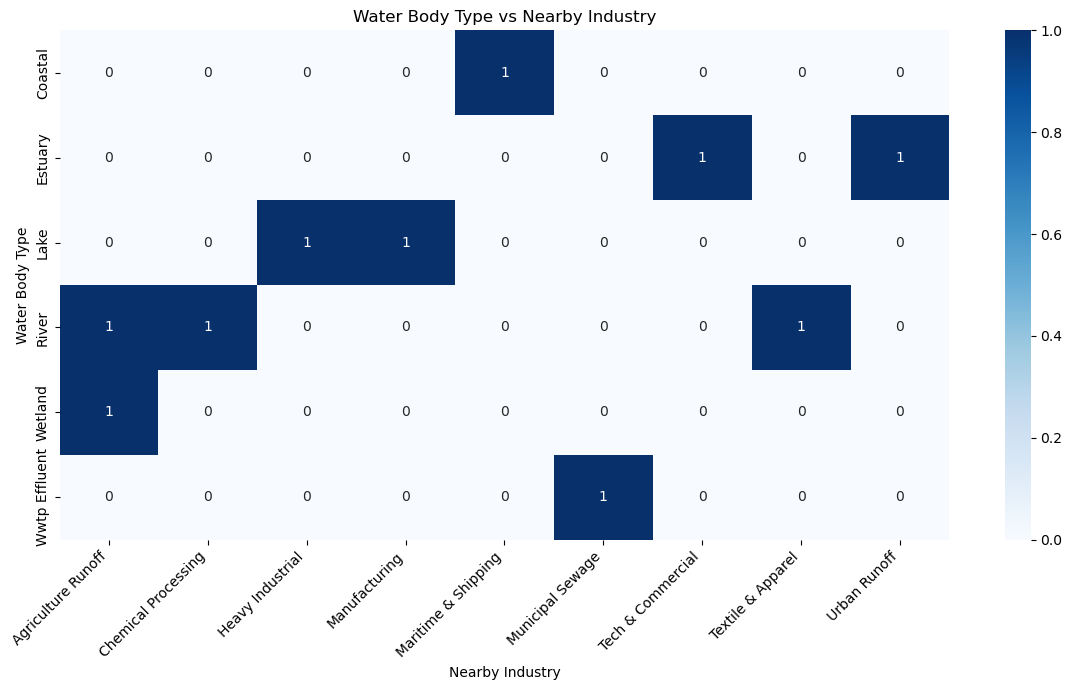

In [5]:
#Water body type vs nearby industry
plt.figure(figsize=(12, 7))

cross_table = pd.crosstab(
    df["Water_Body_Type"],
    df["Nearby_Industry_Type"]
)

sns.heatmap(
    cross_table,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Water Body Type vs Nearby Industry")
plt.xlabel("Nearby Industry")
plt.ylabel("Water Body Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

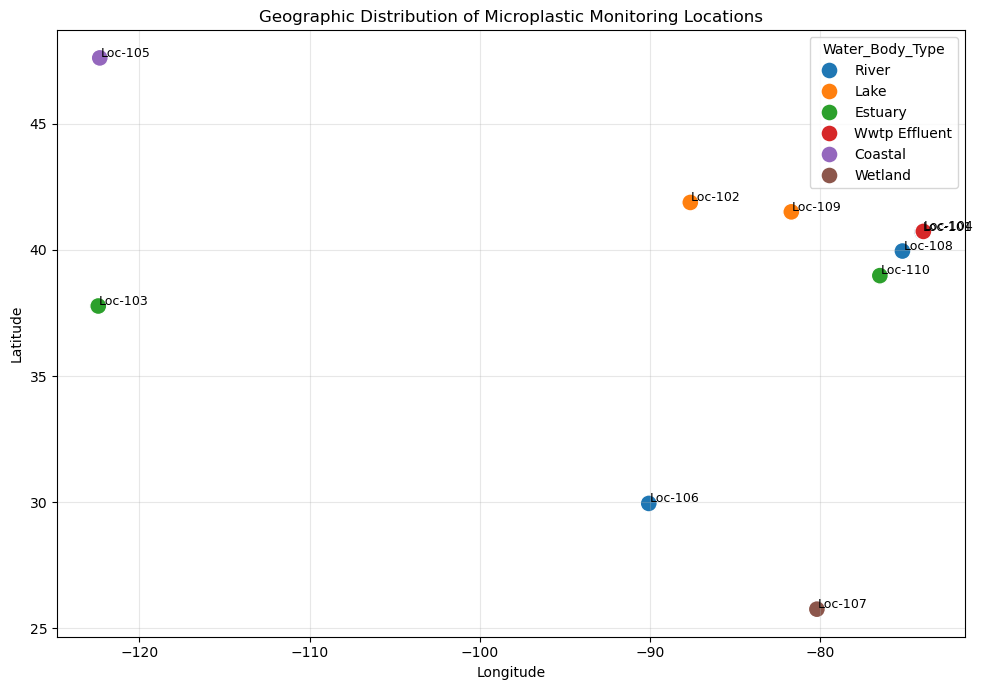

In [6]:
#Geographic distribution of monitoring locations
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Longitude",
    y="Latitude",
    hue="Water_Body_Type",
    s=150
)

for _, row in df.iterrows():
    plt.text(
        row["Longitude"] + 0.05,
        row["Latitude"] + 0.05,
        row["Location_ID"],
        fontsize=9
    )

plt.title("Geographic Distribution of Microplastic Monitoring Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

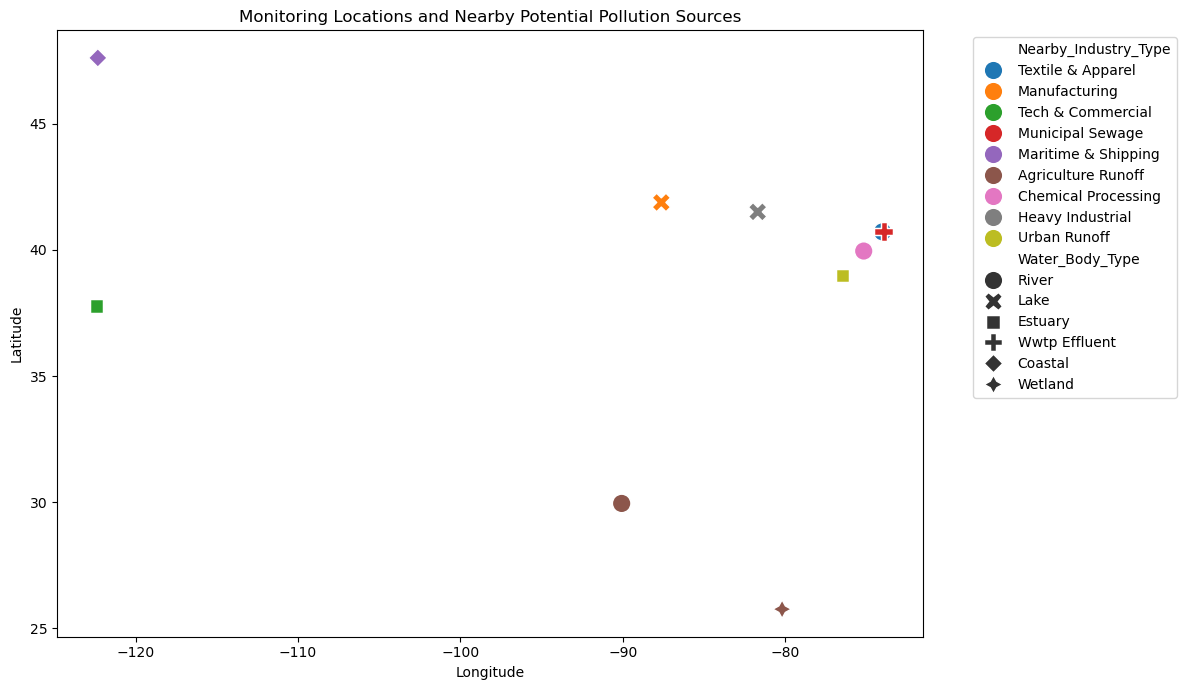

In [7]:
#Location vs nearby industry
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="Longitude",
    y="Latitude",
    hue="Nearby_Industry_Type",
    style="Water_Body_Type",
    s=180
)

plt.title("Monitoring Locations and Nearby Potential Pollution Sources")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

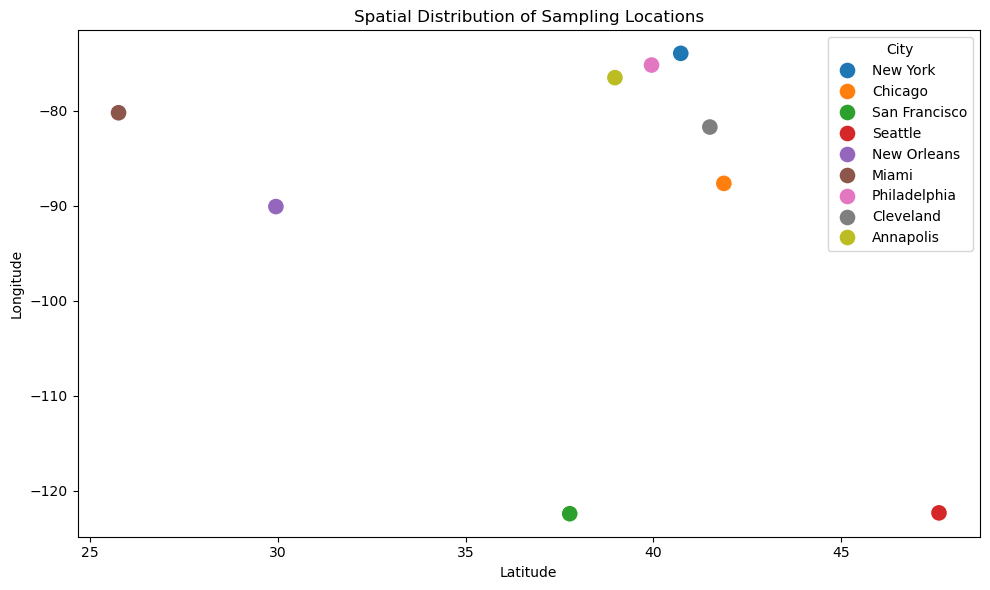

In [8]:
#Latitude and longitude relationship
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Latitude",
    y="Longitude",
    hue="City",
    s=150
)

plt.title("Spatial Distribution of Sampling Locations")
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.tight_layout()
plt.show()

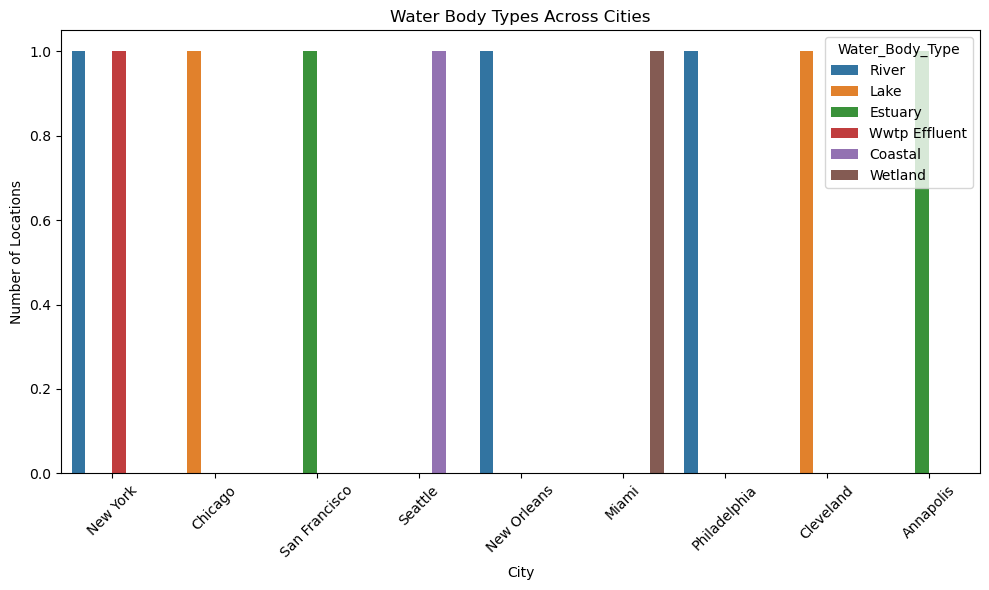

In [9]:
#City and water-body comparison
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="City",
    hue="Water_Body_Type"
)

plt.title("Water Body Types Across Cities")
plt.xlabel("City")
plt.ylabel("Number of Locations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()